# E-Commerce Analytics – Visualization Layer

This notebook visualizes key business insights derived from the SQL analysis.

The focus is on:
- Revenue trends (GMV)
- Customer experience (delivery time vs review score)
- Customer behavior (retention)

All queries are executed directly on the raw CSV files using DuckDB.

In [3]:
import os
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.style.use("seaborn-v0_8-whitegrid")

PRIMARY_COLOR = "steelblue"
ALERT_COLOR = "orange"
GRID_ALPHA = 0.2
FIGSIZE = (10, 5)
DPI = 300

plt.rcParams.update({
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.titlesize": 12
})

os.makedirs("../images", exist_ok=True)

con = duckdb.connect()

In [4]:
df_gmv = con.execute("""
SELECT 
  DATE_TRUNC('month', CAST(o.order_delivered_customer_date AS TIMESTAMP)) AS month,
  SUM(CAST(oi.price AS DOUBLE) + CAST(oi.freight_value AS DOUBLE)) AS gmv
FROM read_csv_auto('../data/raw/olist_order_items_dataset.csv') oi
JOIN read_csv_auto('../data/raw/olist_orders_dataset.csv') o
  ON oi.order_id = o.order_id
WHERE o.order_status = 'delivered'
  AND o.order_delivered_customer_date IS NOT NULL
  AND CAST(o.order_delivered_customer_date AS DATE) < DATE '2018-09-01'
GROUP BY 1
ORDER BY 1
""").df()

df_gmv.head()

,month,gmv
0,2016-10-01,34310.74
1,2016-11-01,11382.15
2,2016-12-01,960.85
3,2017-01-01,38697.02
4,2017-02-01,228077.41


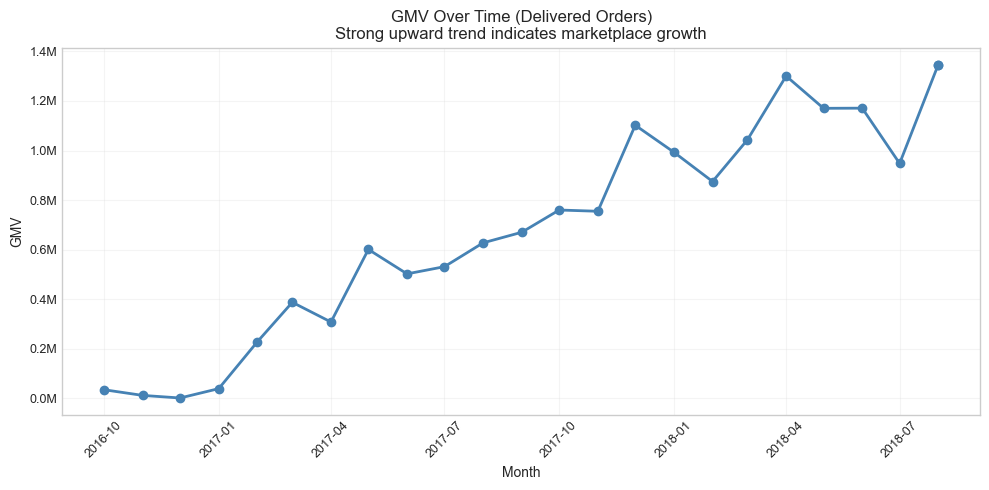

In [5]:
plt.figure(figsize=FIGSIZE)

plt.plot(
    df_gmv["month"],
    df_gmv["gmv"],
    marker="o",
    linewidth=2,
    color=PRIMARY_COLOR
)

plt.scatter(
    df_gmv["month"].iloc[-1],
    df_gmv["gmv"].iloc[-1],
    color=PRIMARY_COLOR
)

plt.title("GMV Over Time (Delivered Orders)\nStrong upward trend indicates marketplace growth")
plt.xlabel("Month")
plt.ylabel("GMV")

plt.xticks(rotation=45)
plt.grid(alpha=GRID_ALPHA)

plt.gca().yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M")
)

plt.tight_layout()
plt.savefig("../images/gmv_over_time.png", dpi=DPI, bbox_inches="tight")
plt.show()

In [6]:
df_reviews = con.execute("""
WITH ranked_reviews AS (
  SELECT
    order_id,
    review_score,
    CAST(review_creation_date AS TIMESTAMP) AS review_created_at,
    ROW_NUMBER() OVER (
      PARTITION BY order_id
      ORDER BY CAST(review_creation_date AS TIMESTAMP) DESC
    ) AS review_recency_rank
  FROM read_csv_auto('../data/raw/olist_order_reviews_dataset.csv')
),

delivery_time AS (
  SELECT 
    order_id,
    DATE_DIFF(
      'day',
      CAST(order_purchase_timestamp AS TIMESTAMP),
      CAST(order_delivered_customer_date AS TIMESTAMP)
    ) AS delivery_days
  FROM read_csv_auto('../data/raw/olist_orders_dataset.csv')
  WHERE order_status = 'delivered'
    AND order_delivered_customer_date IS NOT NULL
    AND order_purchase_timestamp IS NOT NULL
),

delivery_buckets AS (
  SELECT
    order_id,
    CASE
      WHEN delivery_days <= 3 THEN '0-3 days'
      WHEN delivery_days <= 7 THEN '4-7 days'
      WHEN delivery_days <= 14 THEN '8-14 days'
      ELSE '15+ days'
    END AS delivery_bucket,
    CASE
      WHEN delivery_days <= 3 THEN 1
      WHEN delivery_days <= 7 THEN 2
      WHEN delivery_days <= 14 THEN 3
      ELSE 4
    END AS bucket_order
  FROM delivery_time
)

SELECT
  db.bucket_order,
  db.delivery_bucket,
  AVG(rr.review_score) AS avg_review_score,
  COUNT(*) AS num_orders
FROM ranked_reviews rr
JOIN delivery_buckets db
  ON rr.order_id = db.order_id
WHERE rr.review_recency_rank = 1
GROUP BY db.bucket_order, db.delivery_bucket
ORDER BY db.bucket_order
""").df()

df_reviews

,bucket_order,delivery_bucket,avg_review_score,num_orders
0,1,0-3 days,4.462605,6926
1,2,4-7 days,4.397773,23624
2,3,8-14 days,4.298610,37775
3,4,15+ days,3.674679,27499


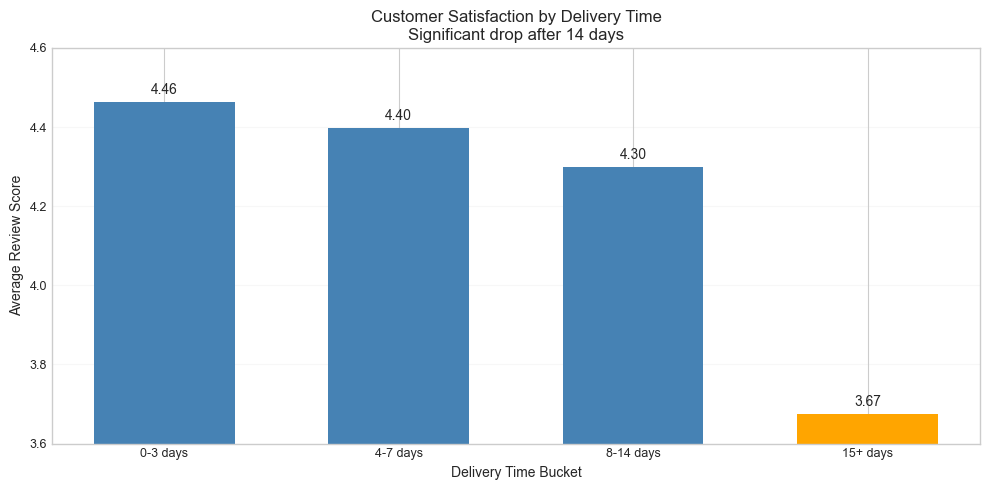

In [7]:
plt.figure(figsize=FIGSIZE)

review_colors = [PRIMARY_COLOR, PRIMARY_COLOR, PRIMARY_COLOR, ALERT_COLOR]

bars = plt.bar(
    df_reviews["delivery_bucket"],
    df_reviews["avg_review_score"],
    width=0.6,
    color=review_colors
)

plt.title("Customer Satisfaction by Delivery Time\nSignificant drop after 14 days")
plt.xlabel("Delivery Time Bucket")
plt.ylabel("Average Review Score")

plt.ylim(3.6, 4.6)
plt.grid(axis="y", alpha=0.15)

for i, v in enumerate(df_reviews["avg_review_score"]):
    plt.text(i, v + 0.02, f"{v:.2f}", ha="center")

plt.tight_layout()
plt.savefig("../images/delivery_time_vs_review_score.png", dpi=DPI, bbox_inches="tight")
plt.show()

In [8]:
df_retention = con.execute("""
WITH orders AS (
  SELECT 
    o.order_id,
    c.customer_unique_id
  FROM read_csv_auto('../data/raw/olist_orders_dataset.csv') o
  JOIN read_csv_auto('../data/raw/olist_customers_dataset.csv') c
    ON o.customer_id = c.customer_id
  WHERE o.order_status = 'delivered'
    AND o.order_delivered_customer_date IS NOT NULL
),

customer_orders AS (
  SELECT 
    customer_unique_id,
    COUNT(order_id) AS num_orders
  FROM orders
  GROUP BY customer_unique_id
)

SELECT 
  CASE 
    WHEN num_orders = 1 THEN 'Single Order'
    ELSE 'Repeat Customer'
  END AS customer_type,
  COUNT(*) AS num_customers
FROM customer_orders
GROUP BY 1
""").df()

df_retention

,customer_type,num_customers
0,Repeat Customer,2801
1,Single Order,90549


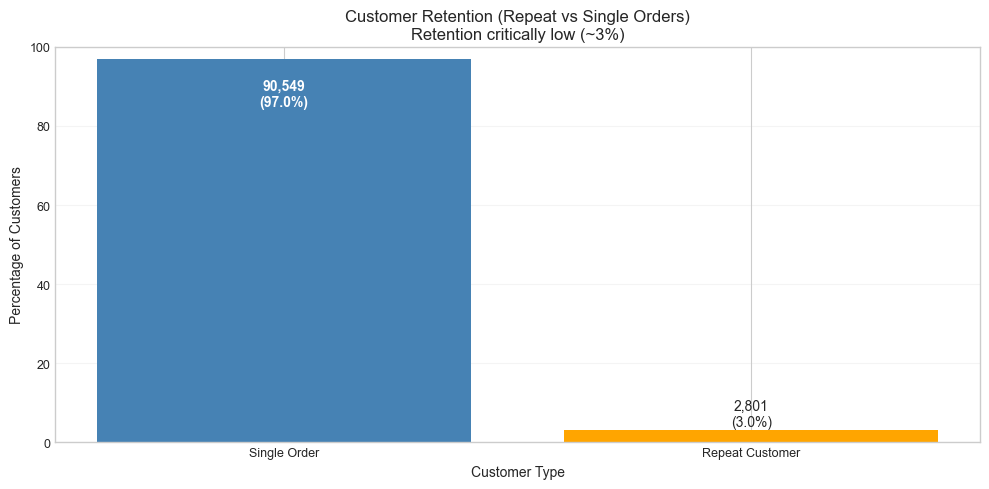

In [9]:
plt.figure(figsize=FIGSIZE)

df_retention_sorted = df_retention.sort_values(
    by="num_customers", ascending=False
)

total = df_retention_sorted["num_customers"].sum()

df_retention_sorted["pct"] = (
    df_retention_sorted["num_customers"] / total * 100
)

retention_colors = [PRIMARY_COLOR, ALERT_COLOR]

bars = plt.bar(
    df_retention_sorted["customer_type"],
    df_retention_sorted["pct"],
    color=retention_colors
)

plt.title("Customer Retention (Repeat vs Single Orders)\nRetention critically low (~3%)")
plt.xlabel("Customer Type")
plt.ylabel("Percentage of Customers")

plt.ylim(0, 100)
plt.grid(axis="y", alpha=GRID_ALPHA)

for i, (v, pct) in enumerate(zip(
    df_retention_sorted["num_customers"],
    df_retention_sorted["pct"]
)):
    if pct > 80:
       plt.text(
        i, pct - 5,
        f"{v:,}\n({pct:.1f}%)",
        ha="center",
        va="top",
        color="white",
        fontweight="bold"
        )
    else:
        plt.text(
            i, pct + 1,
            f"{v:,}\n({pct:.1f}%)",
            ha="center"
        )

plt.tight_layout()
plt.savefig("../images/customer_retention.png", dpi=DPI, bbox_inches="tight")
plt.show()

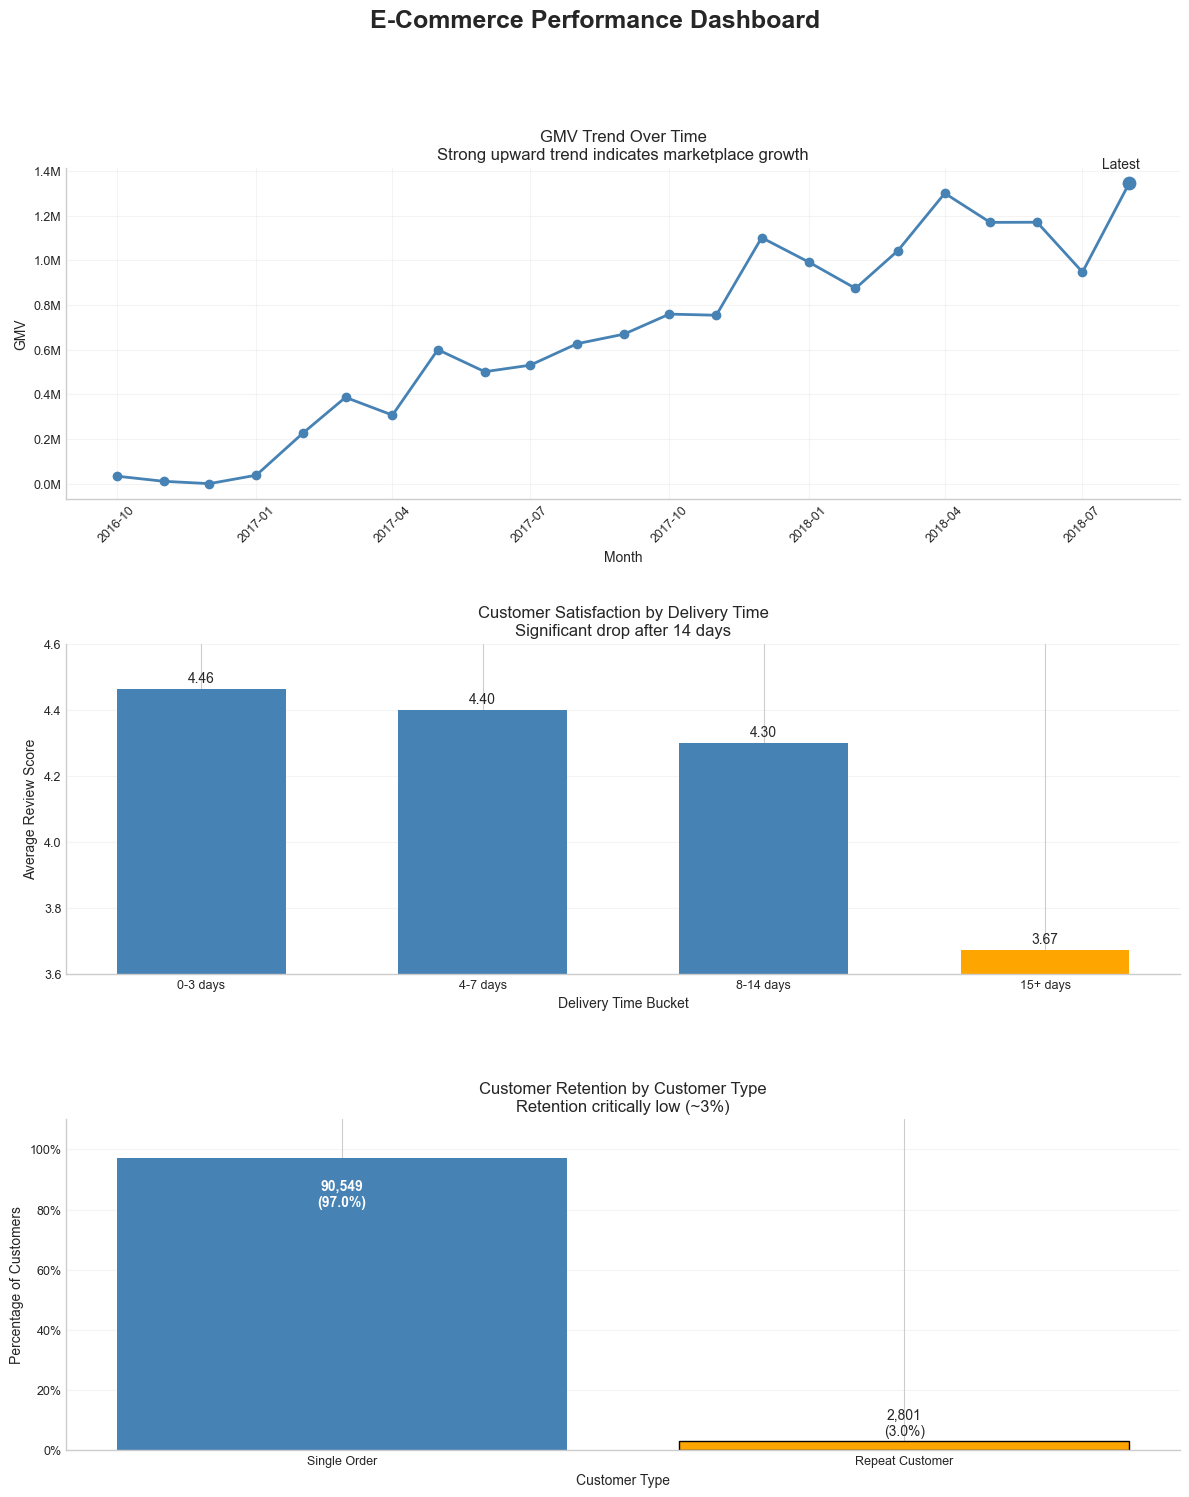

In [12]:
# ========================
# Dashboard: 3 Charts (FINAL CLEAN)
# ========================

fig, axes = plt.subplots(3, 1, figsize=(12, 15))

# ------------------------
# Global Title
# ------------------------
fig.suptitle(
    "E-Commerce Performance Dashboard",
    fontsize=18,
    fontweight="bold",
    y=0.995
)

# ========================
# 1. GMV Over Time
# ========================

axes[0].plot(
    df_gmv["month"],
    df_gmv["gmv"],
    marker="o",
    linewidth=2,
    color=PRIMARY_COLOR
)

# Highlight latest point
axes[0].scatter(
    df_gmv["month"].iloc[-1],
    df_gmv["gmv"].iloc[-1],
    s=80,
    color=PRIMARY_COLOR,
    zorder=3
)

# Better positioned annotation
axes[0].annotate(
    "Latest",
    (df_gmv["month"].iloc[-1], df_gmv["gmv"].iloc[-1]),
    xytext=(-20, 10),
    textcoords="offset points"
)

axes[0].set_title(
    "GMV Trend Over Time\nStrong upward trend indicates marketplace growth"
)
axes[0].set_xlabel("Month")
axes[0].set_ylabel("GMV")

axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(alpha=GRID_ALPHA)

# Format Y-axis to millions
axes[0].yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M")
)

# ========================
# 2. Customer Satisfaction
# ========================

review_colors = [PRIMARY_COLOR, PRIMARY_COLOR, PRIMARY_COLOR, ALERT_COLOR]

axes[1].bar(
    df_reviews["delivery_bucket"],
    df_reviews["avg_review_score"],
    width=0.6,
    color=review_colors
)

axes[1].set_title(
    "Customer Satisfaction by Delivery Time\nSignificant drop after 14 days"
)
axes[1].set_xlabel("Delivery Time Bucket")
axes[1].set_ylabel("Average Review Score")

axes[1].set_ylim(3.6, 4.6)
axes[1].grid(axis="y", alpha=GRID_ALPHA)

# Labels
for i, v in enumerate(df_reviews["avg_review_score"]):
    axes[1].text(i, v + 0.02, f"{v:.2f}", ha="center")

# ========================
# 3. Customer Retention
# ========================

df_retention_sorted = df_retention.sort_values(
    by="num_customers", ascending=False
).copy()

total = df_retention_sorted["num_customers"].sum()

df_retention_sorted["pct"] = (
    df_retention_sorted["num_customers"] / total * 100
)

retention_colors = [PRIMARY_COLOR, ALERT_COLOR]

bars = axes[2].bar(
    df_retention_sorted["customer_type"],
    df_retention_sorted["pct"],
    color=retention_colors
)

axes[2].set_title(
    "Customer Retention by Customer Type\nRetention critically low (~3%)"
)
axes[2].set_xlabel("Customer Type")
axes[2].set_ylabel("Percentage of Customers")

axes[2].set_ylim(0, 110)
axes[2].grid(axis="y", alpha=GRID_ALPHA)

# Format as percentage
axes[2].yaxis.set_major_formatter(mtick.PercentFormatter())

# Labels
for i, (v, pct) in enumerate(zip(
    df_retention_sorted["num_customers"],
    df_retention_sorted["pct"]
)):
    if pct > 80:
        axes[2].text(
            i, pct - 7,
            f"{v:,}\n({pct:.1f}%)",
            ha="center",
            va="top",
            color="white",
            fontweight="bold"
        )
    else:
        axes[2].text(
            i, pct + 2,
            f"{v:,}\n({pct:.1f}%)",
            ha="center"
        )

# Optional: subtle edge highlight for small bar
bars[1].set_edgecolor("black")
bars[1].set_linewidth(1)

# ========================
# Styling Cleanup
# ========================

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ========================
# Layout & Save
# ========================

plt.tight_layout(rect=[0, 0, 1, 0.95], h_pad=3)

plt.savefig(
    "../images/ecommerce_dashboard.png",
    dpi=DPI,
    bbox_inches="tight"
)

plt.show()

## Key Insights

- GMV shows a clear upward trend over time, indicating strong marketplace growth.
- Customer satisfaction declines as delivery times increase.
- The strongest drop in review score occurs when delivery exceeds 14 days.
- Customer retention is very low, with only a small share of customers placing repeat orders.

These findings highlight delivery performance and customer retention as key business levers.